In [1]:
from concurrent.futures import ProcessPoolExecutor
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ast
import RNA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, balanced_accuracy_score,roc_curve, roc_auc_score, auc

In [2]:
# GLOBAL STYLE SETTINGS (run once)

plt.rcParams.update({

    # --- FONT SIZES ---
    "font.size": 24,              # base font size
    "axes.titlesize": 20,         # title
    "axes.labelsize": 36,         # x/y labels
    "xtick.labelsize": 36,
    "ytick.labelsize": 36,
    "legend.fontsize": 16,

    # --- LINES ---
    "lines.linewidth": 5,
    "lines.markersize": 16,

    # --- FIGURE / AXIS ---
    "figure.figsize": (8, 6),
    "figure.dpi": 120,
    "axes.linewidth": 1.5,        # thicker axis spines

    # --- TICKS ---
    "xtick.major.size": 15,
    "xtick.major.width": 3,
    "ytick.major.size": 15,
    "ytick.major.width": 3,

    # --- LEGEND ---
    "legend.frameon": True,
    "legend.framealpha": 0.8,
    "legend.fancybox": True,

    # --- GRID (optional) ---
    #"axes.grid": True,
    #"grid.alpha": 0.3,
})


In [3]:
df=pd.read_csv('../Summary_all.csv')

# I - First classification results

In [4]:
df_1=df[df['Library']=="Lib_1"]
df_1=df_1[df_1['TR_count']>1000]
df_1=df_1[np.array([len(t) for t in df_1['TR']])==70]
df_1 = df_1.groupby('TR')['percentage_mutants'].mean().reset_index()

# keep only rows that meet either condition
df_sub=df_1[
    (df_1['percentage_mutants'] < 0.3) | # bad sequences
    (df_1['percentage_mutants'] > 10)] #good sequences
TR = df_sub['TR']

# assign labels
y = np.where(
    df_sub['percentage_mutants'] < 0.3, 0, 1
)


In [5]:
def feature(seq):
    Sp = 'TCTGTGCCCATCACCTTCTTGCATGGCTCTGCCAACGCTACGGCTTGGCGGGCTGGCCTTTCCTCAATAGGTGGTCAGCCGGTTCTGTCCTGCTTCGGCGAACACGTTACACGGTTCGGCAAAACGTCGATTACTGAAAATGGAAAGGCGGGGCCGACTTC'
    Avd = 'AAGGGCAGGCTGGGAAATAA'

    features = []

    # Base folding energy of TR alone
    fc_base = RNA.fold_compound(seq)
    _, e_tr = fc_base.pf()

    fc_sp = RNA.fold_compound(seq + Sp[:30])
    _, e_tr_sp = fc_sp.pf()
    features.append(e_tr_sp - e_tr)

    return features[0]

def encode_tr_list(seq_list):
    # Parallel processing for each sequence
    with ProcessPoolExecutor() as executor:
        results = list(executor.map(feature, seq_list))
    return results
X = np.array(encode_tr_list(TR)).reshape(-1, 1)

## Fig 4 (a)

Text(0.6, 0.2, 'Average ROC curve\nMean AUC = 0.81\n95% CI: [0.68, 0.91]')

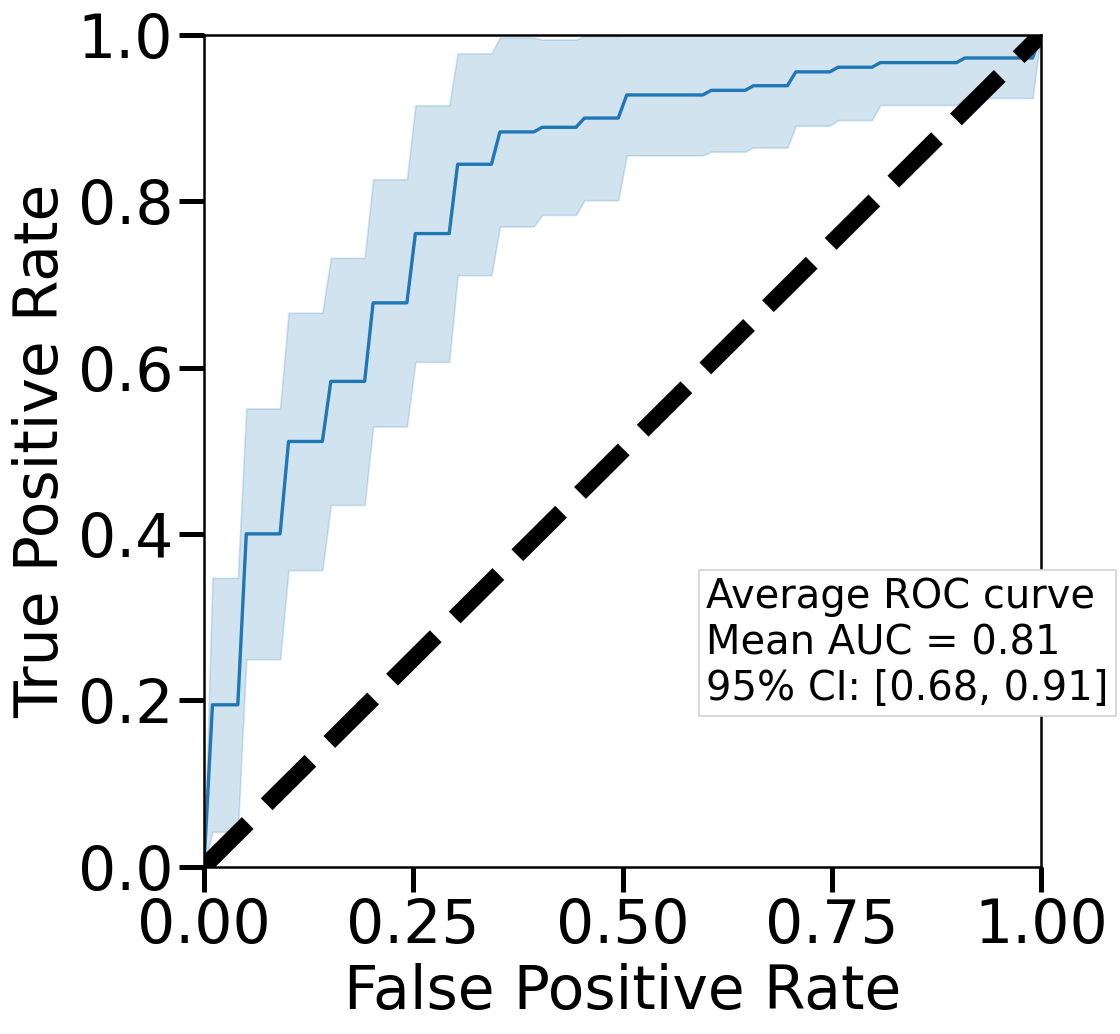

In [7]:
n_splits = 20
fpr_grid = np.linspace(0, 1, 100)

tpr_runs = []
auc_runs = []

for seed in range(n_splits):
    # Split dataset randomly
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    
    # Train logistic regression
    model = LogisticRegression(solver="liblinear", max_iter=int(1e4), class_weight="balanced")
    model.fit(X_train, y_train,)
    y_proba_test = model.predict_proba(X_test)[:, 1]
    
    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_test, pos_label=1)
    roc_auc = auc(fpr, tpr)
    #roc_auc = roc_auc_score(y_test, y_proba_test, average="macro")
    auc_runs.append(roc_auc)
    
    # Interpolate TPR to common grid
    tpr_interp = np.interp(fpr_grid, fpr, tpr)
    tpr_interp[0] = 0.0
    tpr_runs.append(tpr_interp)

# Convert to array
tpr_runs = np.array(tpr_runs)

# Mean and CI across 20 runs
tpr_mean = np.mean(tpr_runs, axis=0)
tpr_std = np.std(tpr_runs, axis=0)
tpr_lower = np.maximum(tpr_mean - tpr_std, 0)
tpr_upper = np.minimum(tpr_mean + tpr_std, 1)

mean_auc = np.mean(auc_runs)
ci_lower = np.percentile(auc_runs, 2.5)
ci_upper = np.percentile(auc_runs, 97.5)

# --- Plot ---
plt.figure(figsize=(9, 9))
plt.plot(fpr_grid, tpr_mean, color="C0", lw=2, label="Average ROC curve")
plt.fill_between(fpr_grid, tpr_lower, tpr_upper, color="C0", alpha=0.2)

plt.plot([0, 1], [0, 1], linestyle="--", color="k", lw=10)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xticks()
plt.yticks()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Add text box with AUC stats
plt.text(
    0.6, 0.2,
    f"Average ROC curve\nMean AUC = {mean_auc:.2f}\n95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]",
    bbox=dict(facecolor="white", edgecolor="lightgray")
)

## Fig 4 (b)

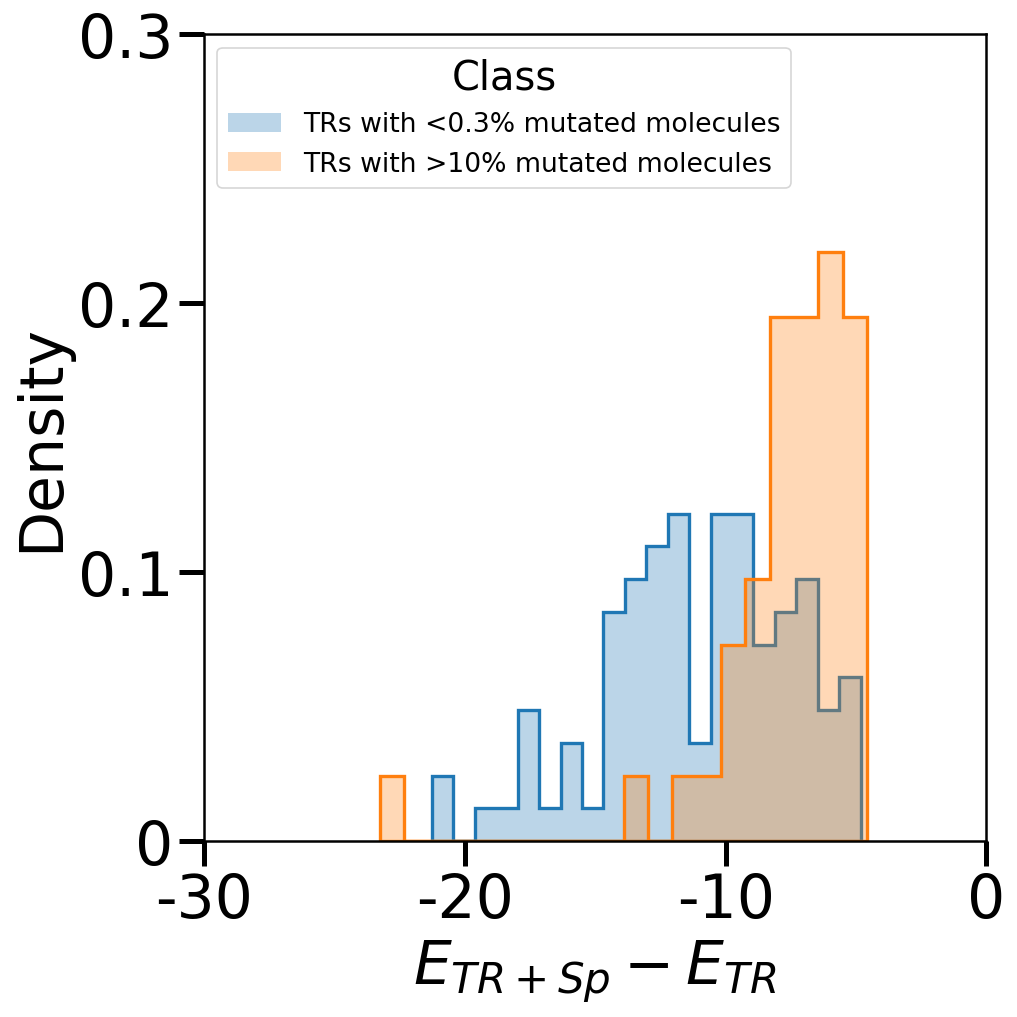

In [8]:
# Generate classifier score curve

fig, ax1 = plt.subplots(figsize=(9, 9))

# Plot overlapping histograms (density)

# Remplissage semi-transparent
ax1.hist(X[y==0], bins=20, density=True, alpha=0.3, facecolor="C0", edgecolor="none",
    label="TRs with <0.3% mutated molecules")
# Contour net
ax1.hist(X[y==0], bins=20, density=True, alpha=1, facecolor="none", histtype="stepfilled",edgecolor="C0", linewidth=2)

# Remplissage semi-transparent
ax1.hist(X[y==1], bins=20, density=True, alpha=0.3, facecolor="C1",histtype="stepfilled", edgecolor="none",
    label="TRs with >10% mutated molecules")
# Contour net
ax1.hist(X[y==1], bins=20, density=True, alpha=1, facecolor="none", edgecolor="C1", histtype="stepfilled",linewidth=2)


# Primary axis formatting
ax1.set_ylabel("Density")
ax1.set_xlabel(r"$E_{TR+Sp} - E_{TR}$")
ax1.set_xticks([-30,-20, -10,0], [-30,-20,-10,0])
ax1.set_yticks([0,0.1,0.2,0.3],[0,0.1,0.2,0.3])

# Legend
ax1.legend(title="Class",loc="upper left")

plt.tight_layout()
plt.savefig("Classifier_results_30.svg")
plt.savefig("Classifier_results_30.png")
plt.show()

# II - Second classification results

In [9]:
df_2=df[df['TR_count']>1000]
df_2=df_2[df_2['Library']=="Lib_2"]

df_2 = df_2.groupby('TR')['percentage_mutants'].mean().reset_index()
print(len(df_2))
# keep only rows that meet either condition
df_sub=df_2[
    (df_2['percentage_mutants'] < 2) |
    (df_2['percentage_mutants'] > 10)]
TR = df_sub['TR']

# assign labels
y = np.where(
    df_sub['percentage_mutants'] < 2, 0, 1
)


460


In [10]:
def feature(seq):
    Sp = 'TCTGTGCCCATCACCTTCTTGCATGGCTCTGCCAACGCTACGGCTTGGCGGGCTGGCCTTTCCTCAATAGGTGGTCAGCCGGTTCTGTCCTGCTTCGGCGAACACGTTACACGGTTCGGCAAAACGTCGATTACTGAAAATGGAAAGGCGGGGCCGACTTC'
    Avd = 'AAGGGCAGGCTGGGAAATAA'

    features = []

    # Base folding energy of TR alone
    fc_base = RNA.fold_compound(seq)
    _, e_tr = fc_base.pf()

    fc_sp = RNA.fold_compound(Avd+seq + Sp[:15])
    _, e_tr_sp = fc_sp.pf()
    features.append(e_tr_sp - e_tr)

    return features[0]

def encode_tr_list(seq_list):
    # Parallel processing for each sequence
    with ProcessPoolExecutor() as executor:
        results = list(executor.map(feature, seq_list))
    return results
X = np.array(encode_tr_list(TR)).reshape(-1, 1)

## Fig 4 (c)

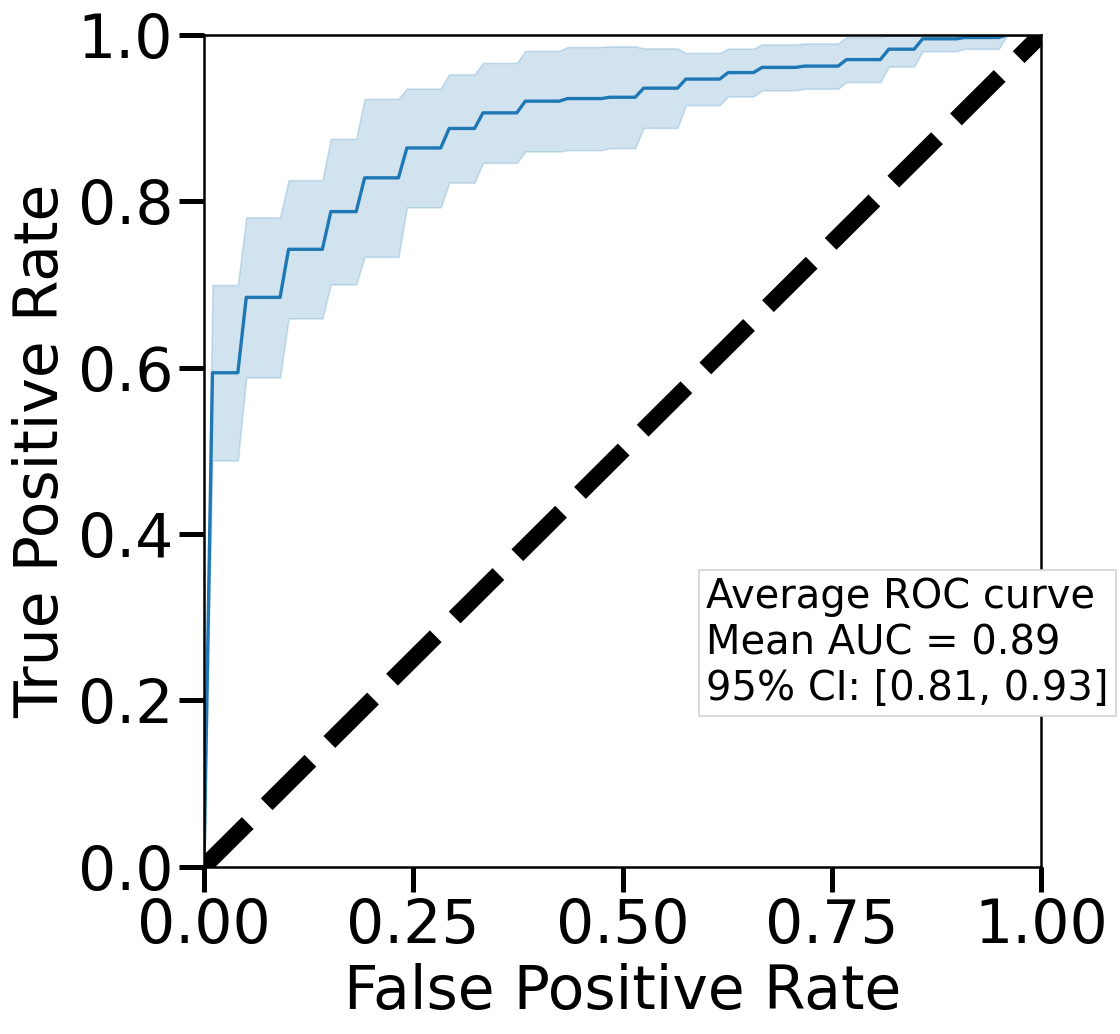

In [11]:
n_splits = 20
fpr_grid = np.linspace(0, 1, 100)

tpr_runs = []
auc_runs = []

for seed in range(n_splits):
    # Split dataset randomly
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    
    # Train logistic regression
    model = LogisticRegression(solver="liblinear", max_iter=int(1e4), class_weight="balanced")
    model.fit(X_train, y_train,)
    y_proba_test = model.predict_proba(X_test)[:, 1]
    
    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_test, pos_label=1)
    roc_auc = auc(fpr, tpr)
    #roc_auc = roc_auc_score(y_test, y_proba_test, average="macro")
    auc_runs.append(roc_auc)
    
    # Interpolate TPR to common grid
    tpr_interp = np.interp(fpr_grid, fpr, tpr)
    tpr_interp[0] = 0.0
    tpr_runs.append(tpr_interp)

# Convert to array
tpr_runs = np.array(tpr_runs)

# Mean and CI across 20 runs
tpr_mean = np.mean(tpr_runs, axis=0)
tpr_std = np.std(tpr_runs, axis=0)
tpr_lower = np.maximum(tpr_mean - tpr_std, 0)
tpr_upper = np.minimum(tpr_mean + tpr_std, 1)

mean_auc = np.mean(auc_runs)
ci_lower = np.percentile(auc_runs, 2.5)
ci_upper = np.percentile(auc_runs, 97.5)

# --- Plot ---
plt.figure(figsize=(9, 9))
plt.plot(fpr_grid, tpr_mean, color="C0", lw=2, label="Average ROC curve")
plt.fill_between(fpr_grid, tpr_lower, tpr_upper, color="C0", alpha=0.2)

plt.plot([0, 1], [0, 1], linestyle="--", color="k", lw=10)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xticks()
plt.yticks()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Add text box with AUC stats
plt.text(
    0.6, 0.2,
    f"Average ROC curve\nMean AUC = {mean_auc:.2f}\n95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]",
    bbox=dict(facecolor="white", edgecolor="lightgray")
)
plt.savefig("AUC_15_second_classifier.svg")
plt.show()

## Fig 4 (d)

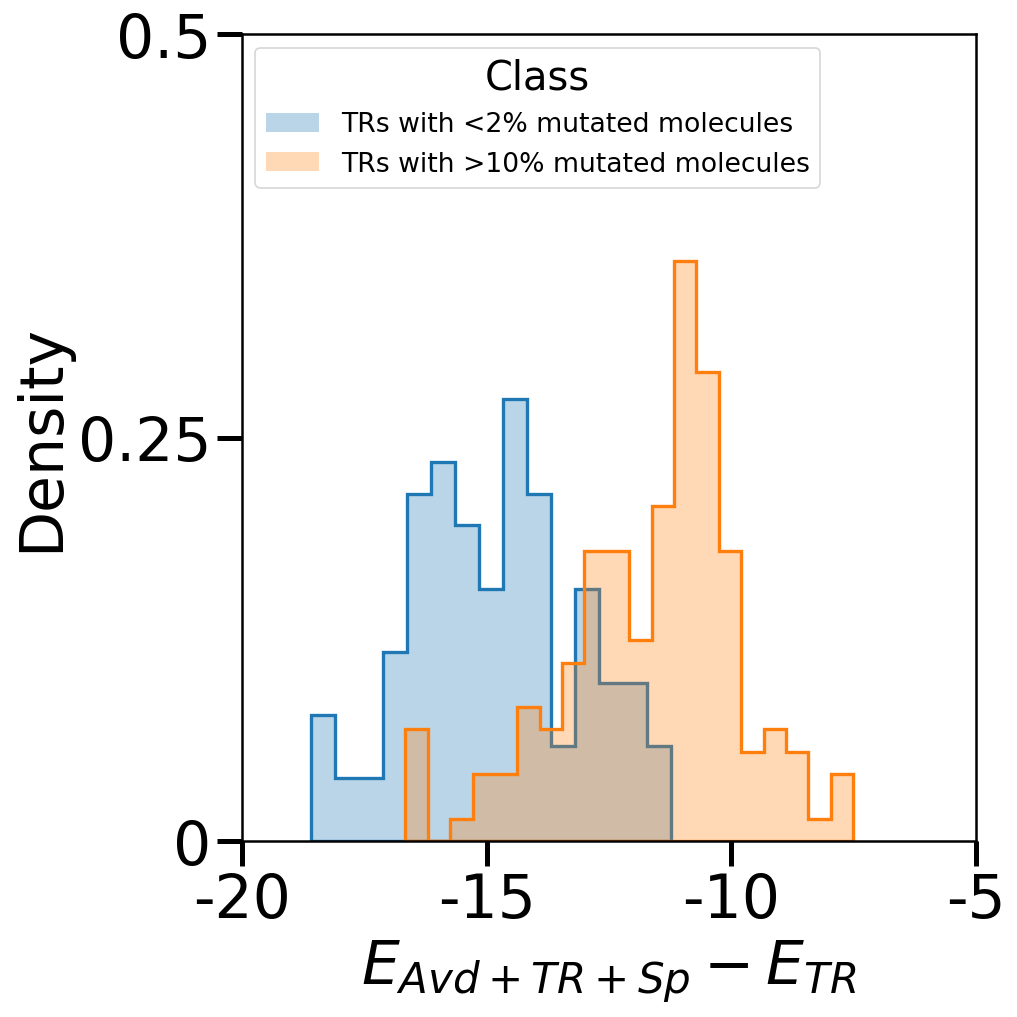

In [12]:
# Generate classifier score curve

fig, ax1 = plt.subplots(figsize=(9, 9))

# Plot overlapping histograms (density)

# Remplissage semi-transparent
ax1.hist(X[y==0], bins=15, density=True, alpha=0.3, facecolor="C0", edgecolor="none",
    label="TRs with <2% mutated molecules")
# Contour net
ax1.hist(X[y==0], bins=15, density=True, alpha=1, facecolor="none", histtype="stepfilled",edgecolor="C0", linewidth=2)

# Remplissage semi-transparent
ax1.hist(X[y==1], bins=20, density=True, alpha=0.3, facecolor="C1",histtype="stepfilled", edgecolor="none",
    label="TRs with >10% mutated molecules")
# Contour net
ax1.hist(X[y==1], bins=20, density=True, alpha=1, facecolor="none", edgecolor="C1", histtype="stepfilled",linewidth=2)


# Primary axis formatting
ax1.set_ylabel("Density")
ax1.set_xlabel(r"$E_{Avd+TR+Sp} - E_{TR}$")
ax1.set_xticks([-20,-15, -10,-5], [-20,-15,-10,-5])
ax1.set_yticks([0,0.25,0.5],[0,0.25,0.5])

# Legend
ax1.legend(title="Class",loc="upper left")

plt.tight_layout()
plt.savefig("Classifier_results_15.svg")
plt.savefig("Classifier_results_15.png")
plt.show()
